# Spotify Popularity Prediction using Machine Learning

This project explores whether Spotify audio features can be used to predict song popularity using supervised machine learning techniques.

The goal is to classify songs as:
- Popular (popularity ≥ 60)
- Not Popular (popularity < 60)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Data Loading

In this section, we load the Spotify dataset and inspect its structure to understand the available features and data types.

In [3]:
df = pd.read_csv("SpotifyFeatures M6.csv")

df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


## Data Exploration

We explore the dataset to understand:
- Number of rows and columns
- Data types
- Missing values
- Distribution of the popularity variable

In [4]:
df.shape
df.info()
df.isna().sum()
df['popularity'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

count    232725.000000
mean         41.127502
std          18.189948
min           0.000000
25%          29.000000
50%          43.000000
75%          55.000000
max         100.000000
Name: popularity, dtype: float64

## Data Preprocessing

The popularity score is converted into a binary classification label:
- 1 = Popular (≥ 60)
- 0 = Not Popular (< 60)

This allows us to frame the problem as a classification task.

In [5]:
df['popular'] = df['popularity'].apply(lambda x: 1 if x >= 60 else 0)

df[['track_name', 'artist_name', 'popularity', 'popular']].head()

,track_name,artist_name,popularity,popular
0,C'est beau de faire un Show,Henri Salvador,0,0
1,Perdu d'avance (par Gad Elmaleh),Martin & les fées,1,0
2,Don't Let Me Be Lonely Tonight,Joseph Williams,3,0
3,Dis-moi Monsieur Gordon Cooper,Henri Salvador,0,0
4,Ouverture,Fabien Nataf,4,0


## Class Distribution

We examine how many songs are labeled as popular vs not popular to check for class imbalance.

In [9]:
df['popular'].value_counts()

popular
0    196271
1     36454
Name: count, dtype: int64

In [10]:
df['popular'].value_counts(normalize=True)

popular
0    0.84336
1    0.15664
Name: proportion, dtype: float64

## Feature Selection

We select relevant numerical audio features that will be used as inputs for the machine learning model.

In [11]:
features = [
    'acousticness',
    'danceability',
    'duration_ms',
    'energy',
    'instrumentalness',
    'liveness',
    'loudness',
    'speechiness',
    'tempo',
    'valence'
]

X = df[features]
y = df['popular']

## Train-Test Split

The dataset is split into training and testing sets using an 80/20 split to evaluate model performance on unseen data.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Feature Scaling

Since K-Nearest Neighbors relies on distance calculations, we standardize the features so all variables contribute equally.

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training (K-Nearest Neighbors)

We use the K-Nearest Neighbors (KNN) algorithm with k=5 to classify songs based on their similarity to other songs.

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


## Predictions

The trained model is used to predict labels on the test dataset.

In [15]:
y_pred = knn.predict(X_test_scaled)

## Model Evaluation

We evaluate the model using:
- Accuracy score
- Confusion matrix
- Classification report

These metrics help us understand how well the model performs.

In [16]:
accuracy = accuracy_score(y_test, y_pred)

accuracy

0.8378558384359223

In [17]:
confusion_matrix(y_test, y_pred)

array([[36015,  3239],
       [ 4308,  2983]])

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91     39254
           1       0.48      0.41      0.44      7291

    accuracy                           0.84     46545
   macro avg       0.69      0.66      0.67     46545
weighted avg       0.83      0.84      0.83     46545



## Prediction Results

We compare the model’s predictions with the actual labels to determine which predictions are correct and incorrect.

In [19]:
results = X_test.copy()

results['actual'] = y_test

results['predicted'] = y_pred

results['correct'] = results['actual'] == results['predicted']

results.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,actual,predicted,correct
201578,0.947,0.370,51387,0.122,0.968000,0.115,-17.393,0.0415,119.597,0.4320,0,0,True
62472,0.575,0.520,272653,0.105,0.000000,0.119,-10.399,0.0410,132.403,0.0577,0,0,True
112165,0.730,0.425,286957,0.406,0.000004,0.107,-8.911,0.1760,184.061,0.1240,1,1,True
16351,0.132,0.568,240093,0.683,0.000000,0.100,-4.103,0.0361,115.015,0.2340,0,1,False
171278,0.806,0.660,330280,0.722,0.000000,0.829,-7.804,0.9350,119.591,0.1240,0,0,True


## Error Analysis

We examine incorrectly classified songs to understand where the model struggles.

In [20]:
wrong_predictions = results[results['correct'] == False]

wrong_predictions.head()

,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,actual,predicted,correct
16351,0.13200,0.568,240093,0.683,0.000000,0.100,-4.103,0.0361,115.015,0.234,0,1,False
141250,0.10900,0.504,189235,0.448,0.000024,0.102,-6.581,0.0291,84.172,0.357,1,0,False
117243,0.07870,0.756,175686,0.625,0.000015,0.111,-7.906,0.1580,153.102,0.518,0,1,False
149509,0.00417,0.768,199380,0.589,0.000027,0.136,-8.991,0.0403,97.979,0.757,1,0,False
20209,0.01300,0.708,155840,0.827,0.000015,0.504,-4.591,0.0453,120.015,0.367,1,0,False


In [21]:
song_info = df.loc[X_test.index, ['track_name', 'artist_name', 'genre', 'popularity']]

wrong_songs = song_info.copy()
wrong_songs['actual'] = y_test
wrong_songs['predicted'] = y_pred
wrong_songs['correct'] = y_test == y_pred

wrong_songs[wrong_songs['correct'] == False].head(5)

,track_name,artist_name,genre,popularity,actual,predicted,correct
16351,For the Love of a Daughter,Demi Lovato,Dance,57,0,1,False
141250,Heal Me,Grace Carter,Indie,64,1,0,False
117243,Lies About You (feat. Lil Durk),Gunna,Rap,58,0,1,False
149509,Bad Vibrations,Jesper Jenset,Pop,69,1,0,False
20209,Let Me Love You - Tiësto's AFTR:HRS Mix,DJ Snake,Dance,60,1,0,False


## Visualizations

We visualize:
- Class distribution
- Model performance using confusion matrix

These help provide a clearer understanding of the results.

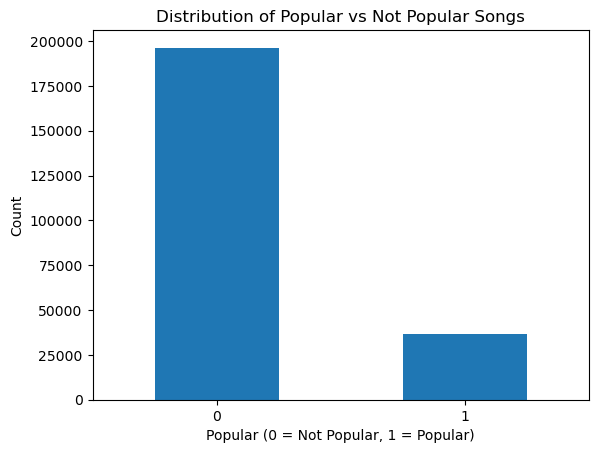

In [22]:
import matplotlib.pyplot as plt

df['popular'].value_counts().plot(kind='bar')
plt.title('Distribution of Popular vs Not Popular Songs')
plt.xlabel('Popular (0 = Not Popular, 1 = Popular)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

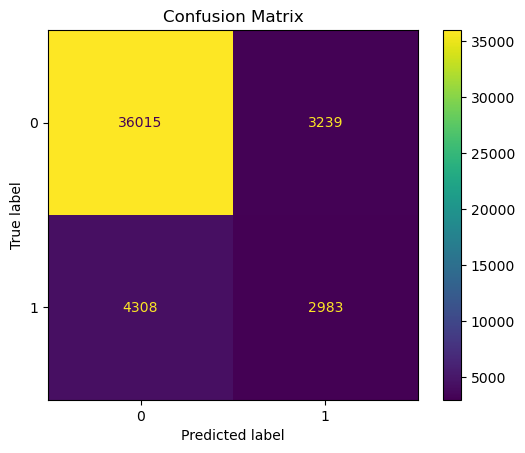

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()

## Conclusion

In this project, we used supervised machine learning to predict whether a Spotify song is popular based on its audio features. Using a K-Nearest Neighbors (KNN) model, we achieved an accuracy of approximately 83.8%.

However, further evaluation showed that the model performs much better at identifying non-popular songs than popular ones. This is largely due to class imbalance in the dataset and the limited features used. Many prediction errors occurred near the popularity threshold, highlighting the difficulty of clearly separating songs into two categories.

Overall, this project demonstrates that while audio features provide useful insights, they are not sufficient on their own to fully explain song popularity. Additional factors such as artist popularity, marketing, and listener trends would likely improve model performance.